# Kapitel 6 Klustring

## Uppgift 1
Klustring är en form av oövervakad inlärning (unsupervised learning) där data grupperas baserat på likheter utan färdiga etiketter eller svar.
Exempel: Kundsegmentering för marknadsföring, bildsegmentering, avvikelsedetektering och rekommendationer.

## Uppgift 2
Hur K-means fungerar (figur 6.3 och 6.4):
1. Välj k slumpmässiga startpunkter (centroider).
2. Tilldelning (fig 6.3): Varje datapunkt tilldelas den närmaste centroiden.
3. Uppdatering (fig 6.4): Centroidernas positioner flyttas till medelvärdet av alla punkter i respektive kluster.
4. Steg 2 och 3 upprepas tills centroiderna inte längre flyttar sig.

## Uppgift 3
Hur man väljer antal kluster:
- Inertia: Summan av de kvadrerade avstånden från varje punkt till dess centroid. Minskar alltid med fler kluster; med elbow-metoden letar man efter den punkt där minskningen planar ut.
- Silhouette score: Mäter hur nära punkterna ligger sitt eget kluster jämfört med grannklustret (från -1 till +1, där högre är bättre).
- Silhouette diagram: Visar silhuettvärdet för varje enskild observation per kluster för att se om klustren är jämna och väl separerade.

## Uppgift 4
Figur 6.10 visar silhuettanalys för olika antal kluster. Man väljer det k där snittvärdet är högt och klustren är jämna. Att välja antal kluster är inte en exakt vetenskap utan en avvägning mellan matematiska mått och vad som är praktiskt användbart.

## Uppgift 5
Figur 6.13 visar begränsningar med K-means när kluster inte är runda/sfäriska eller har olika täthet. K-means förutsätter runda kluster och delar därför felaktigt upp långsträckta eller komplexa former.

## Uppgift 7
K-means klustring på housing.csv.

   median_income  latitude  longitude
0         8.3252     37.88    -122.23
1         8.3014     37.86    -122.22
2         7.2574     37.85    -122.24
3         5.6431     37.85    -122.25
4         3.8462     37.85    -122.25
   median_income  latitude  longitude Cluster
0         8.3252     37.88    -122.23       2
1         8.3014     37.86    -122.22       2
2         7.2574     37.85    -122.24       2
3         5.6431     37.85    -122.25       2
4         3.8462     37.85    -122.25       1


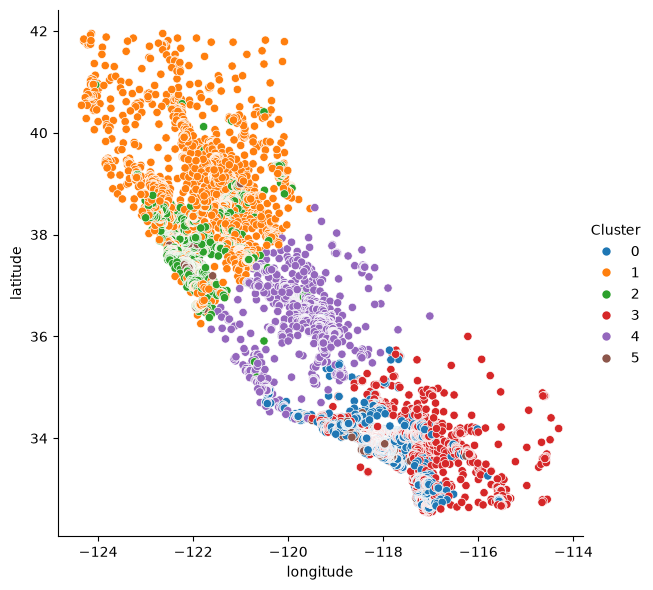

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans

df = pd.read_csv('../data/housing.csv')
X = df.loc[:, ["median_income", "latitude", "longitude"]].copy()
print(X.head())

kmeans = KMeans(n_clusters=6, random_state=42)
X["Cluster"] = kmeans.fit_predict(X)
X["Cluster"] = X["Cluster"].astype("category")
print(X.head())

sns.relplot(
    x="longitude", y="latitude", hue="Cluster", data=X, height=6
)
plt.show()

a) Förklaring av koden:
Koden väljer ut medianinkomst samt latitud och longitud från housing.csv. Den tränar K-means med 6 kluster för att gruppera områden baserat på geografiskt läge och inkomstnivå, och ritar upp klustren på en karta över Kalifornien med Seaborn relplot.

b) Marknadsundersökning:
I en marknadsundersökning per kluster hade följande varit intressant att undersöka:
- Demografi och boende: Åldersfördelning, familjestorlek och om man föredrar villa eller lägenhet.
- Kommunikationskanaler: Hur de föredrar att bli kontaktade (digitalt, post, telefon).
- Ekonomi: Prisklass vid framtida bostadsköp och efterfrågade tillval.
Undersökningen kan designas som riktade enkäter och intervjuer anpassade efter klustrens geografiska och ekonomiska profil.

c) Affärsnytta för företag:
- Bygg- och mäklarbolag kan anpassa bostadstyper och prissättning efter områdets köpkraft.
- Företag kan rikta marknadsföring till höginkomst- respektive låginkomstområden.
- Butikskedjor och banker kan välja lämpliga platser för nya etableringar.

d) Undersökning av antal kluster med elbow-metoden:

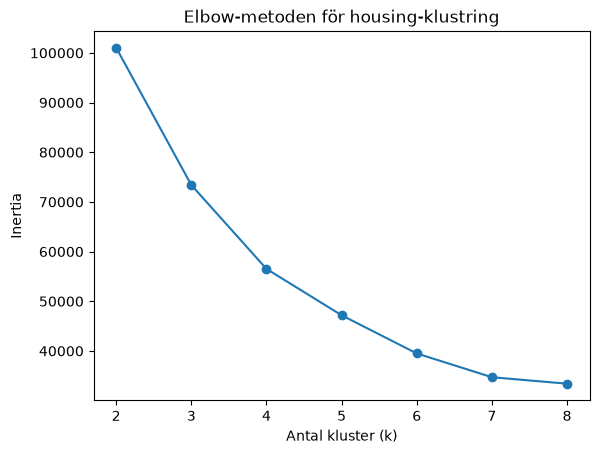

In [2]:
inertias = []
X_features = df.loc[:, ["median_income", "latitude", "longitude"]]

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42).fit(X_features)
    inertias.append(km.inertia_)

plt.plot(range(2, 9), inertias, marker='o')
plt.xlabel('Antal kluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow-metoden för housing-klustring')
plt.show()

Slutsats 7d:
Elbow-grafen visar att minskningen i inertia planar ut runt k=5 eller k=6, vilket bekräftar att 6 kluster är ett rimligt val för att fånga både geografiska områden och inkomstskillnader.

## Uppgift 9
Klustringsanalys på 1980s Classic Hits with Spotify Data.

In [3]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

songs = pd.read_csv('../data/1980sClassics.csv')
features = ['Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo']
X_audio = songs[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_audio)

scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores[k] = score
    print(f"k={k}: Silhouette Score = {score:.4f}")

best_k = max(scores, key=scores.get)
print(f"\nHögst silhouette score vid k={best_k}")

final_kmeans = KMeans(n_clusters=best_k, random_state=42)
X_audio['Cluster'] = final_kmeans.fit_predict(X_scaled)
print("\nMedelvärden för ljudegenskaper per kluster:")
print(X_audio.groupby('Cluster').mean().round(3))

k=2: Silhouette Score = 0.2347
k=3: Silhouette Score = 0.2266
k=4: Silhouette Score = 0.1925
k=5: Silhouette Score = 0.1879
k=6: Silhouette Score = 0.1524

Högst silhouette score vid k=2

Medelvärden för ljudegenskaper per kluster:
         Danceability  Energy  Loudness  ...  Liveness  Valence    Tempo
Cluster                                  ...                            
0               0.668   0.727    -7.729  ...     0.187    0.707  121.873
1               0.529   0.416   -11.577  ...     0.160    0.362  118.650

[2 rows x 9 columns]
